# Notebook 1: High frequency momentum signals in BTC 

Goal - identify *profitable/not profitable* momentum signals for BTC @ high frequency (10s ticks). 

In [2]:
%load_ext autoreload
%autoreload 2

import datetime as dt
from datetime import timedelta, datetime, date, time
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import plotly.graph_objects as go 
import mplfinance as mpf
from scipy.stats import pearsonr

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100)

from data_processing import make_bid_ask_features, calc_net_returns
from test_momentum import test_correlation, simple_momentum_backtest

In [3]:
raw_df = pd.read_parquet('data/btc_level1crypto_origin_times_resampled.parquet')
df = make_bid_ask_features(raw_df)
train_df = df.loc[:'2025-09-01'].ffill()

<Axes: xlabel='origin_time'>

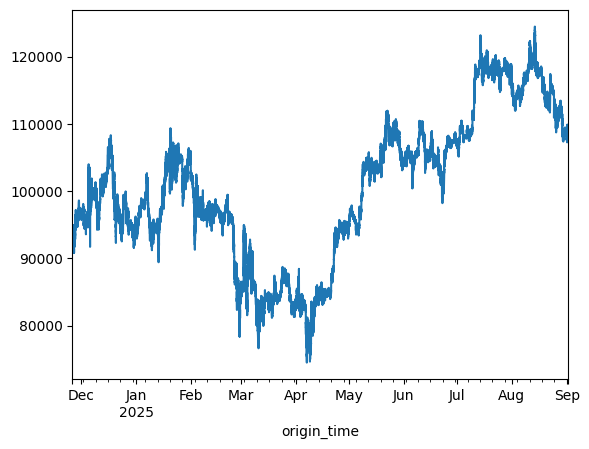

In [6]:
train_df['mid'].plot()

# Signal 1: Time Series Momentum 

Time series momentum means that past returns are positively correlated with future returns. 

The most straightforward test proposed by Ernie Chang just computes the correlation between returns for a set of predefined lookback and holding periods. And then we develop a trading strategy based on lookback/holding periods that gives us the maximum correlation which is also statistically significant.

However, I have some problems with this: 
- Distributional assumptions
  - crypto returns are fat tailed, whereas measuring correlation implicitly assumes normality of returns (since for normal distributions, correlation structure captures the dependence)
  - Not only looking for linear dependence structure 
- How much correlation is economically meaningful i.e. large enough to be profitable? 
- Overfitting risk - if we try too many lookback/holding periods, this amounts to data mining 
- No economic reason why lookback/holding periods would be fixed
  - Not like comparing return correlations for instruments such as futures, which have an "implicit" timeline since the time to maturity is baked in. 

Therefore, to initially model/study the time series momentum we use a variety of statistical/empirical tests to triangulate certain properties. These properties will then inform a trading strategy. 

## Test 1 - Percentile Ranks via Spearman's Rho 

Measures correlation between the RANKS - therefore quantifies presence of ANY kind of monotonic relationship (not just linear). In particular, this deals with the problem of fat-tailed returns/extreme values. Some guidelines: 
- Can use approximate p-value since sample is large 
- Also, make sure the lookback/holding periods are non-overlapping 
  - Correlation/significance testing relies on independence

In [6]:
from eda import plot_kde 
TICKS_TO_MIN = 6 
PERIOD_MINS = [1, 10, 60] #30 seconds, 1 minute, 10 minutes, 1 hour, 6 hours
PERIODS = [p*TICKS_TO_MIN for p in PERIOD_MINS] 
FEE = 0.001 
net_returns_df = calc_net_returns(train_df, holding_periods = PERIODS, fee = FEE)

The first thing to observe is that returns are extremely fat tailed. 

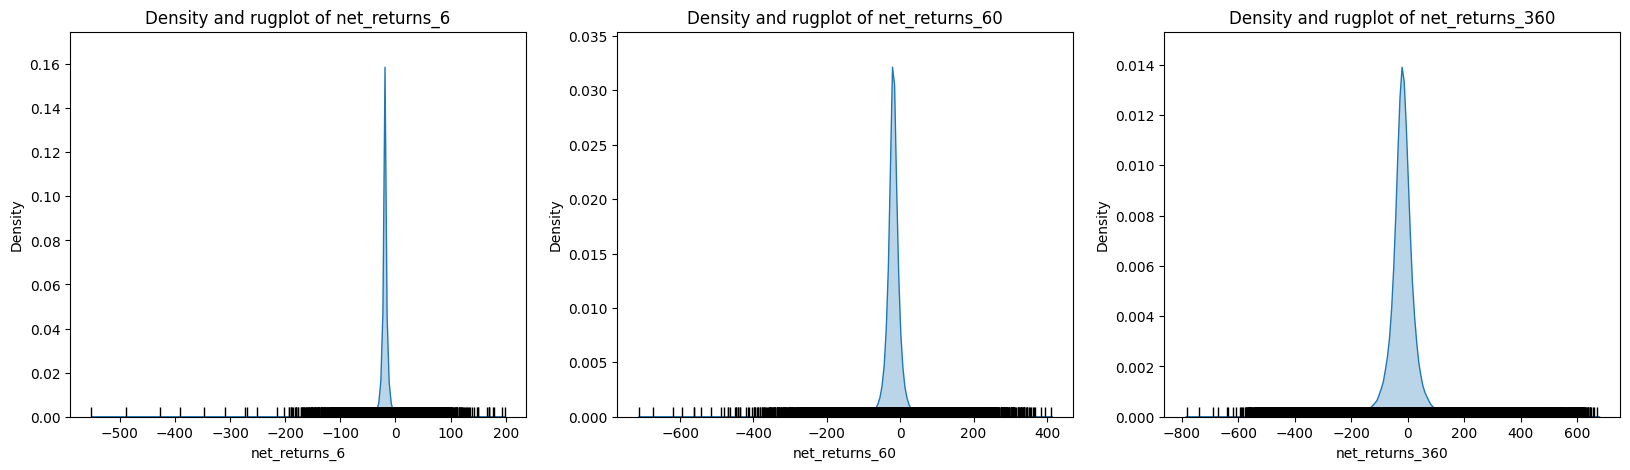

In [ ]:
fig, ax = plt.subplots(ncols = len(PERIODS), figsize = (20, 5))
for a, period in zip(ax, PERIODS): 
    plot_kde(net_returns_df, col = f"net_returns_{period}", ax = a)

Note that to initially test for momentum we will just look at the gross returns as a starting point. 

In [23]:
period_mins = [0.5, 1, 10, 60, 360] #30 seconds, 1 minute, 10 minutes, 1 hour, 6 hours
periods = [int(p*TICKS_TO_MIN) for p in period_mins]
test_correlation(prices = train_df['mid'], lookback = PERIODS, holding = periods, method = 'spearman').sort_values(by = 'correlation', key = lambda x: x.abs(), ascending=False)

,lookback,holding,correlation,pvalue,n
11,360,6,-0.103065,2.470868e-17,6719
10,360,3,-0.096468,2.291424e-15,6719
12,360,60,-0.083358,7.732311e-12,6719
13,360,360,-0.045201,2.105432e-04,6718
4,6,2160,0.037976,2.042981e-01,1119
0,6,3,0.036845,3.908993e-121,403199
7,60,60,-0.027202,4.685611e-08,40318
3,6,360,0.026959,2.712013e-02,6719
5,60,3,-0.026319,1.253746e-07,40319
14,360,2160,-0.023309,4.360134e-01,1119


It is interesting to see that most correlations are negative or close to zero, which suggests that we DON'T really have momentum effects at the 10 second level. 

There is a possibility of some short term momentum effects with a short lookback and a short holding period - see (6,3). 

However: 
- It is not quite immediately obvious how we can rigorously justify that a spearman's correlation of 0.03 is not large enough to profitably trade on.
  - From a commonsense perspective, most likely NOT 
- We have also done quite a few p-value tests so run into data mining risk - it is suspicious that there aren't any other correlations. 

Further investigation is needed as to whether or not there is potential for very short term momentum. 

## Is a time series momentum strategy profitable? 

Since we know that returns are NOT normally distributed, we can't analytically compute expected returns based on just the correlation. 

Perhaps the most robust way to estimate profitability given a correlation estimate is just to prototype a simple trading strategy as a kind of baseline. 

In [28]:
simple_momentum_backtest(prices = train_df['mid'], lookback = 6, holding = 3)

lb=6, h=3 | mean=0.14 bps | hit=44.83% | n=403199


origin_time
2024-11-26 00:01:00   -0.001381
2024-11-26 00:02:00   -0.000129
2024-11-26 00:03:00   -0.000514
2024-11-26 00:04:00    0.001760
2024-11-26 00:05:00   -0.000146
                         ...   
2025-09-01 23:55:00   -0.000290
2025-09-01 23:56:00   -0.000168
2025-09-01 23:57:00    0.000077
2025-09-01 23:58:00   -0.000084
2025-09-01 23:59:00   -0.000034
Name: mid, Length: 403199, dtype: float64

Since the fee is 0.1% for both buy/sell, this backtest shows that time series momentum strategy is likely **UNPROFITABLE**. To be extra precise we could also measure statistical significance, but given that we cannot even achieve in-sample profitability, there is probably not much point. 

## A note on empirical modelling peaks/troughs 

An interesting approach taken by one paper is to parametrically model the momentum effects for an asset by looking at peak/trough cycles of the smoothed asset price series. This approach lacks statistical rigour but it is perhaps more economically meaningful since it allows us to more directly and empirically understand the momentum dynamics of a given price series. 

**Crucial: Furthermore, it allows us to investigate momentum effects where the lookback/holding periods may be DYNAMIC, which our previous test above cannot capture**. 

**Core Idea: Momentum Cycle**
- A (positive) momentum cycle is a (peak, trough, peak, trough) seqeuence where the second peak is HIGHER than the first peak and the second trough is HIGHER than the second trough. 
  - This captures the idea of an equilibrium shift in prices. 
- The initial momentum cycle is called the formation period. 
- A series of momentum cycles strung together is called a momentum period. 

From this lens, *momentum* is defined as whether or not an initial momentum cycle (i.e upshift in equilibrium prices) is followed by *more* momentum cycles. In other words, whether or an initial upshift in prices predicts a further upshift in prices. 

**Moving Average Filter**

The paper looks at momentum cycles by looking at a moving average filter, but note this introduces arbitrariness. So this is definitely not a robust statistical test of any kind. 
The most honest approach is to use a variety of sensitivity/lookback values that line up with what we tested above. 

**Decision**

On balance, I have decided not to utilise this empirical modelling approach of peaks/troughs. Two main reasons: 
- MA smoothing filter - how to choose the parameter? 
- MA smoothing - implicitly means we are looking for *longer term* momentum signals, so not relevant at 10s frequency. 

## Time Series Momentum - Conclusions 

The ultimate conclusion is that time series momentum is likely not a profitable trading strategy at the 10s frequency.

**Further Research/Things we haven't gotten to yet**
- TODO - why negative correlation between hour + short term returns? 

# Signal 2 - Order Book Imbalances

The more economically reliable signal for high frequency momentum trading is order book imbalance, since it directly reflects the buying/selling pressure at that instance.

We will try to answer the following three questions: 
1. How strong is the evidence for order flow momentum? 
2. In general, how can we utilise order flow information to PREDICT future price movements in BTC? 
3. GIVEN this prediction, how can we create a profitable trading strategy? 

In [31]:
from scipy.stats import spearmanr

In [4]:
train_df['obi'] = (train_df['bid_size'] - train_df['ask_size']) / (train_df['bid_size'] + train_df['ask_size']) #Take as a ratio 

In [7]:
#Periods 
period_mins = [0.5, 1, 10, 60, 360] #30 seconds, 1 minute, 10 minutes, 1 hour, 6 hours
periods = [int(p*TICKS_TO_MIN) for p in period_mins]
net_returns_df = calc_net_returns(train_df, holding_periods = periods, fee = FEE)
net_returns_df['obi'] = train_df['obi']

In [ ]:
net_returns_df.corr(method = 'spearman')['obi']

net_returns_3       0.192183
net_returns_6       0.134487
net_returns_60      0.038838
net_returns_360     0.015129
net_returns_2160    0.006023
obi                 1.000000
Name: obi, dtype: float64

As expected, short term returns are positively correlated with OBI but this correlation degrades as our holding period gets longer. 

## Profitability Estimates 

Since OBI as a ratio is bounded between (0,1), the most straightforward way to estimate profitability of an OBI-based strategy is to bin returns based on OBI. 

In [9]:
from eda import qq_plot 

In [41]:
gross_returns_df = calc_net_returns(train_df, holding_periods = periods, fee = 0.0)
gross_returns_df['obi'] = train_df['obi']

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


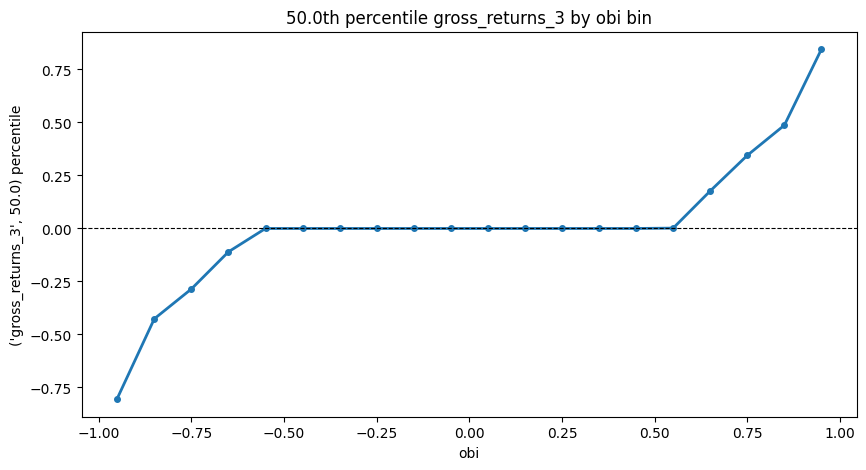

In [42]:
qq_plot(gross_returns_df, x = 'obi', y = 'gross_returns_3')

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


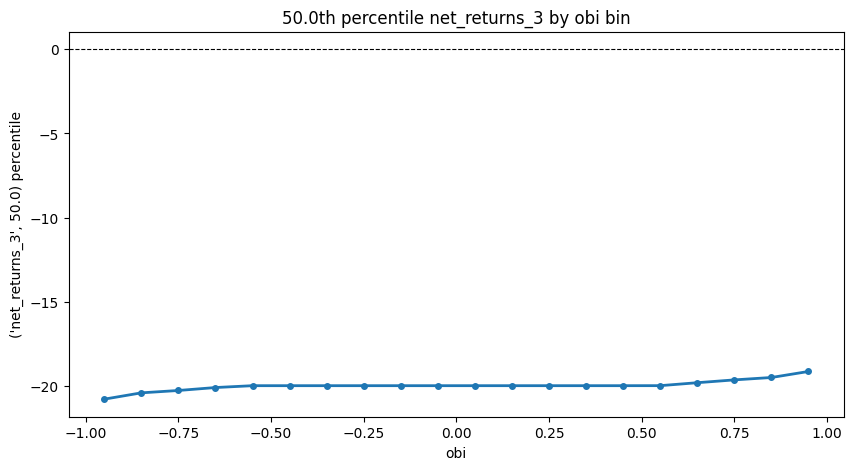

In [43]:
qq_plot(net_returns_df, x = 'obi', y = 'net_returns_3')

The plots clearly show that whilst OBI DOES have a predictive effect for more extreme imbalances, any possible returns are generally eaten up by fees! This result is replicated when we increase the quantile.

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


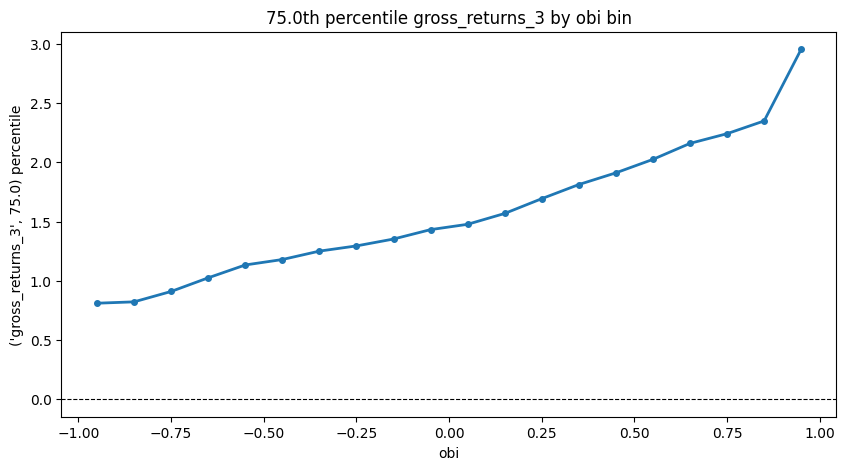

In [46]:
qq_plot(gross_returns_df, x = 'obi', y = 'gross_returns_3', quantile = 0.75)

# Zoom Out - Lower Frequencies 

The conclusion here is that high frequency momentum strategies for BTC are not profitable. In large part this is due to the fact that price movements at the 10s level (whether positive or negative) are just too small, full stop. 

A natural question to ask is whether we are looking at too granular a frequency, hence being eaten alive by fees. We will try upsampling to a 1 minute or 5 minute frequency to see if our momentum signals are profitable. 

## Order flow momentum- 5 minute ticks 

In [48]:
#5 minute trading frequency 
periods = [3, #15 minutes
           6, #30 mins 
           12, #1 hour
           36    # 3 hours 
           ]
train_df_5mins = train_df.resample('5min').last()
gross_returns_df = calc_net_returns(train_df_5mins, holding_periods = periods, fee = 0.0)
gross_returns_df['obi'] = train_df_5mins['obi']
gross_returns_df.corr(method = 'spearman')['obi']

gross_returns_3     0.027213
gross_returns_6     0.020547
gross_returns_12    0.015244
gross_returns_36    0.008949
obi                 1.000000
Name: obi, dtype: float64

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


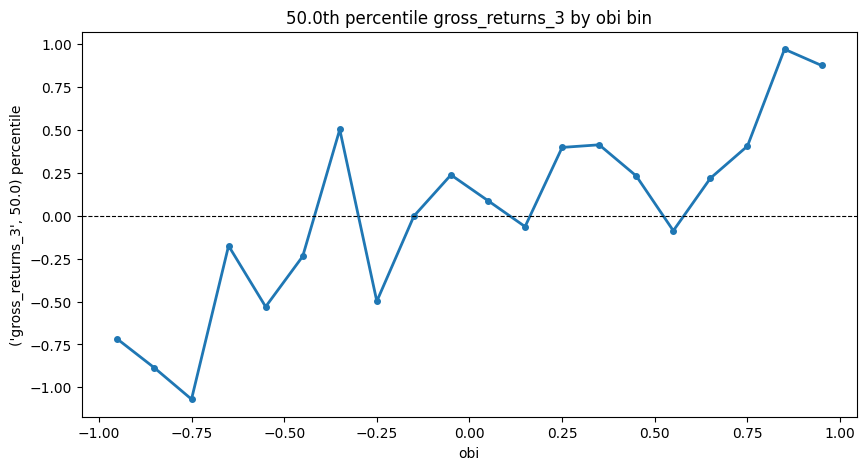

In [49]:
qq_plot(gross_returns_df, x = 'obi', y = 'gross_returns_3', quantile = 0.5)

The relationship between order book imbalance and future returns is not as smooth/monotonic as in 10s frequency case. Furthermore, returns are still NOT large enough! If we scale up to look at the 90th percentile of returns (per OBI bin), we finally obtain positive returns but by then the monotonic relationship between OBI and future returns is largely brokwn down. 

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


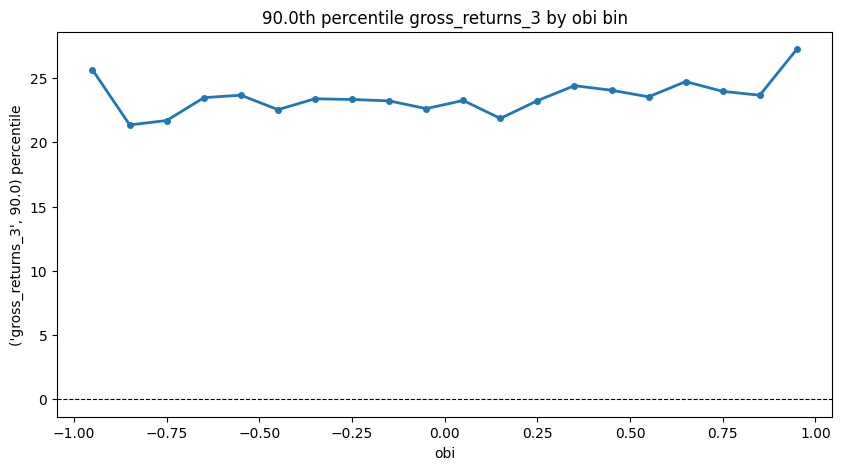

In [50]:
qq_plot(gross_returns_df, x = 'obi', y = 'gross_returns_3', quantile = 0.9)

## Time Series Momentum - 5 minute/1 hour ticks 

In [51]:
periods = [3, #15 minutes
           6, #30 mins 
           12, #1 hour
           36,   # 3 hours 
           288 # 1 day 
           ]
test_correlation(prices = train_df_5mins['mid'], lookback = periods, holding = periods, method = 'spearman').sort_values(by = 'correlation', key = lambda x: x.abs(), ascending=False)

,lookback,holding,correlation,pvalue,n
23,288,36,-0.177497,2.928572e-03,279
22,288,12,-0.171794,4.001084e-03,279
20,288,3,-0.154562,9.719336e-03,279
21,288,6,-0.108989,6.910560e-02,279
24,288,288,-0.105395,7.938585e-02,278
14,12,288,-0.098460,1.007531e-01,279
16,36,6,-0.084928,5.729603e-05,2239
15,36,3,-0.073162,5.310705e-04,2239
4,3,288,-0.056685,3.455071e-01,279
9,6,288,-0.046960,4.346297e-01,279


Interestingly, there is still no evidence of meaningful momentum signals. 

In [52]:
train_df_1hour = train_df.resample('1h').last()
gross_returns_df = calc_net_returns(train_df_1hour, holding_periods = periods, fee = 0.0)
gross_returns_df['obi'] = train_df_1hour['obi']
gross_returns_df.corr(method = 'spearman')['obi']

periods = [6, 24, 168]
test_correlation(prices = train_df_1hour['mid'], lookback = periods, holding = periods, method = 'spearman').sort_values(by = 'correlation', key = lambda x: x.abs(), ascending=False)

gross_returns_3      0.023122
gross_returns_6      0.010848
gross_returns_12    -0.007478
gross_returns_36    -0.004097
gross_returns_288   -0.002673
obi                  1.000000
Name: obi, dtype: float64

,lookback,holding,correlation,pvalue,n
5,24,168,-0.220648,0.177074,39
3,24,6,-0.191122,0.001338,279
7,168,24,-0.177530,0.279598,39
6,168,6,-0.112146,0.496686,39
4,24,24,-0.089431,0.136915,278
2,6,168,0.072267,0.661968,39
8,168,168,-0.063136,0.706492,38
1,6,24,0.044221,0.461927,279
0,6,6,0.026174,0.381930,1118


In [53]:
train_df_1D = train_df.resample('1D').last()
gross_returns_df = calc_net_returns(train_df_1D, holding_periods = periods, fee = 0.0)
gross_returns_df['obi'] = train_df_1D['obi']
gross_returns_df.corr(method = 'spearman')['obi']

periods = [6, 24, 168]
test_correlation(prices = train_df_1D['mid'], lookback = periods, holding = periods, method = 'spearman').sort_values(by = 'correlation', key = lambda x: x.abs(), ascending=False)

gross_returns_6     -0.004066
gross_returns_24     0.041389
gross_returns_168    0.075161
obi                  1.000000
Name: obi, dtype: float64

,lookback,holding,correlation,pvalue,n
0,6,6,0.098814,0.518411,45
1,6,24,0.063636,0.852539,11
3,24,6,0.063636,0.852539,11
4,24,24,0.006061,0.986743,10
2,6,168,NaN,NaN,1
5,24,168,NaN,NaN,1
6,168,6,NaN,NaN,1
7,168,24,NaN,NaN,1
8,168,168,NaN,NaN,0


Our sample size is not so good on the training data but this does prove the result that momentum trading strategies for crypto are properly only profitable at lower rather than higher frequencies. 